# Worksheet 3 | Quantum Convolutional Neural Networks

In this worksheet, we explore Quantum Convolutional Neural Networks (QCNNs), which adapt the successful concepts of classical CNNs to the quantum domain. QCNNs are particularly well-suited for image classification and pattern recognition tasks.

**Topics covered:**
- **Convolutional Layers**: Local feature extraction using parameterized quantum gates
- **Pooling Layers**: Dimensionality reduction through quantum measurements
- **Hierarchical Feature Extraction**: Multi-scale processing of information
- **Image Classification**: Applying QCNNs to digit recognition

**Learning Objectives:**
1. Understand the architecture of quantum convolutional neural networks
2. Implement convolutional and pooling layers using PennyLane
3. Train a QCNN for image classification
4. Analyze the expressibility and generalization behavior of QCNNs

## Introduction

Classical CNNs have revolutionized computer vision by leveraging:

1. **Local Connectivity**: Each neuron only connects to a local region of the input
2. **Parameter Sharing**: The same filters are applied across the entire input
3. **Hierarchical Processing**: Stacking layers to extract increasingly abstract features

QCNNs adapt these principles to quantum computing:

1. **Quantum Convolutions**: Parameterized gates acting on neighboring qubits
2. **Quantum Pooling**: Measurement-based dimensionality reduction
3. **Entanglement**: Natural feature extraction through quantum correlations

The QCNN architecture:

```
Input Image → Quantum Encoding → [Conv + Pool] × N → Fully Connected → Output
```

In [1]:
# Setup: Import required libraries
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt
from sklearn import datasets
import seaborn as sns

# Set random seed for reproducibility
seed = 42
np.random.seed(seed)
rng = np.random.default_rng(seed=seed)

# Set up quantum device
num_wires = 6
dev = qml.device("default.qubit", wires=num_wires)

print("Setup complete! Ready to build Quantum CNNs.")
print(f"PennyLane version: {qml.__version__}")

Setup complete! Ready to build Quantum CNNs.
PennyLane version: 0.45.0


## 1) Quantum Convolutional Layers

A quantum convolutional layer applies parameterized gates to neighboring qubits, similar to how classical convolutions slide filters across the input:

1. **Single-qubit rotations**: $U_3(\theta, \phi, \lambda)$ gates on each qubit
2. **Two-qubit interactions**: Ising-type gates ($XX, YY, ZZ$) between neighbors

The convolutional operation can be written as:

$$U_{conv}(\theta) = \prod_{(i,j) \in \text{pairs}} \text{Ising}(\theta_{ij}) \cdot \prod_i R_i(\theta_i)$$

where pairs are chosen to cover all neighboring qubit connections.

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> a) Implement a Convolutional Layer</h3>
  
  Implement a quantum convolutional layer that:
  
  1. Apply U3 rotations to each qubit
  2. Apply [IsingZZ](https://docs.pennylane.ai/en/stable/code/api/pennylane.IsingZZ.html) gates between neighboring qubits
  3. Follow a checkerboard pattern for parallel operations
  
  <hr>
  <i class="fas fa-wrench" style="font-size: 20px"></i> &nbsp; <strong>Variables:</strong>
  <ul>
    <li><code>weights</code>: shape (13,) - parameters for U3 and Ising gates</li>
    <li><code>wires</code>: list of qubit indices to apply the layer on</li>
  </ul>
  <hr>
  
  <a href="help/tips_03_1a.ipynb"><i class="fas fa-life-ring" style="font-size:20px"></i> &nbsp;Hint</a>
</div>

In [ ]:
# Exercise 1a: Implement a Convolutional Layer

def convolutional_layer(weights, wires):
    """
    Apply a quantum convolutional layer.
    
    Args:
        weights: array of shape (13,) with parameters for:
                 - weights[:3]: U3 params for qubit i
                 - weights[3:6]: U3 params for qubit i+1
                 - weights[6]: IsingZZ gate param
                 - weights[7:10]: U3 params for qubit i (after Ising)
                 - weights[10:]: U3 params for qubit i+1 (after Ising)
        wires: list of wire indices to apply the layer on
    """
    n_wires = len(wires)
    assert n_wires >= 2, "Convolutional layer requires at least 2 qubits"
    
    # YOUR CODE HERE
    # Step 1: Apply U3 rotations to pairs of qubits
    # Step 2: Apply IsingZZ gates between neighbors
    # Step 3: Apply second set of U3 rotations
    for p in [0, 1]:
        for index, wire in enumerate(wires):
            if index % 2 == p and index < n_wires - 1:
                if index % 2 == 0:
                    qml.U3(*weights[:3], wires=[wire])
                    qml.U3(*weights[3:6], wires=[wires[index + 1]])
                qml.IsingZZ(weights[6], wires=[wire, wires[index + 1]])
                qml.U3(*weights[7:10], wires=[wire])
                qml.U3(*weights[10:], wires=[wires[index + 1]])
    pass

# Test the convolutional layer
test_weights = np.random.rand(13)
test_wires = [0, 1, 2, 3]

@qml.qnode(dev)
def test_conv_circuit(weights, wires):
    convolutional_layer(weights, wires)
    return qml.expval(qml.PauliZ(0))

result = test_conv_circuit(test_weights, test_wires)
print(f"Convolutional layer test result: {result:.4f}")
print("\nCircuit structure:")
print(qml.draw(convolutional_layer)(test_weights, test_wires))

Convolutional layer test result: 0.9625

Circuit structure:
0: ──U3(0.18,0.78,0.60)─╭IsingZZ(0.33)──U3(0.14,0.65,0.06)────────────────────────────────────┤  
1: ──U3(0.45,0.10,0.46)─╰IsingZZ(0.33)──U3(0.72,0.94,0.00)─╭IsingZZ(0.33)──U3(0.14,0.65,0.06)─┤  
2: ──U3(0.18,0.78,0.60)─╭IsingZZ(0.33)──U3(0.14,0.65,0.06)─╰IsingZZ(0.33)──U3(0.72,0.94,0.00)─┤  
3: ──U3(0.45,0.10,0.46)─╰IsingZZ(0.33)──U3(0.72,0.94,0.00)────────────────────────────────────┤  


## 2) Quantum Pooling Layers

Pooling layers reduce the spatial dimensions of the data. In QCNNs, this is achieved through:

1. **Measurement**: Collapse one qubit and use the result to condition operations on another
2. **Conditional Operations**: Apply gates to the "kept" qubit based on measurement outcomes

The pooling operation can be written as:

$$|\psi\rangle = \sum_i \alpha_i |i\rangle \otimes |j\rangle \rightarrow \sum_i \alpha_i |f(i, j)\rangle$$

where $f$ is a function that combines the states based on measurement outcomes.

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> a) Implement a Pooling Layer</h3>
  
  Implement a quantum pooling layer that:
  
  <ol>
    <li>Measures every second qubit (the "pooled" qubits)</li>
    <li>Uses the measurement outcome to condition U3 gates on the neighboring qubit</li>
    <li>Keeps only the unmeasured qubits for the next layer</li>
  </ol>
  
  <hr>
  <i class="fas fa-wrench" style="font-size: 20px"></i> &nbsp; <strong>Variables:</strong>
  <ul>
    <li><code>weights</code>: array of shape (3,) - U3 parameters for conditional gates</li>
    <li><code>wires</code>: list of wire indices to apply pooling on</li>
  </ul>
  <hr>
  
  <a href="help/tips_03_2a.ipynb"><i class="fas fa-life-ring" style="font-size:20px"></i> &nbsp;Hint</a>
</div>

In [3]:
# Exercise 2a: Implement a Pooling Layer

def pooling_layer(weights, wires):
    """
    Apply a quantum pooling layer.
    
    Args:
        weights: array of shape (3,) - U3 parameters for conditional gates
        wires: list of wire indices to apply pooling on
    """
    n_wires = len(wires)
    assert n_wires >= 2, "Pooling layer requires at least 2 qubits"
    
    # YOUR CODE HERE
    # Step 1: For each pair (even index, odd index), measure the odd qubit
    # Step 2: Use the measurement outcome to condition U3 on the even qubit
    # Hint: Use qml.cond() for classical conditioning
    for index, wire in enumerate(wires):
        if index % 2 == 1 and index < n_wires:
            m_outcome = qml.measure(wire)
            qml.cond(m_outcome, qml.U3)(*weights, wires=wires[index - 1])

# Test the pooling layer
test_weights = np.random.rand(3)
test_wires = [0, 1, 2, 3]

@qml.qnode(dev)
def test_pool_circuit(weights, wires):
    pooling_layer(weights, wires)
    return qml.probs(wires=[0, 2])

result = test_pool_circuit(test_weights, test_wires)
print(f"Pooling layer test result (probabilities on kept qubits):")
print(result)
print(qml.draw(test_pool_circuit)(test_weights, test_wires))

Pooling layer test result (probabilities on kept qubits):
[1. 0. 0. 0.]
0: ───────U3(0.99,0.62,0.61)──────────────────────────┤ ╭Probs
1: ──┤↗├──║───────────────────────────────────────────┤ │     
2: ───║───║────────────────────────U3(0.99,0.62,0.61)─┤ ╰Probs
3: ───║───║───────────────────┤↗├──║──────────────────┤       
      ╚═══╝                    ╚═══╝                          


## 3) Complete QCNN Architecture

A complete QCNN consists of:

1. **Data Encoding**: Amplitude embedding of the input image
2. **Convolutional Blocks**: Alternating conv and pooling layers
3. **Fully Connected Layer**: Final classification layer
4. **Measurement**: Output class probabilities

The architecture progressively reduces the number of qubits while increasing the expressiveness of the remaining qubits through entanglement and parameterized gates.

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> a) Build a Complete QCNN</h3>
  
  Build a complete QCNN for binary classification by:
  
  <ol>
    <li>Use amplitude embedding to encode the input</li>
    <li>Apply 2 convolutional + pooling blocks</li>
    <li>Add a fully connected layer on the remaining qubits</li>
    <li>Measure class probabilities</li>
  </ol>
  
  <hr>
  <i class="fas fa-wrench" style="font-size: 20px"></i> &nbsp; <strong>Variables:</strong>
  <ul>
    <li><code>conv_weights</code>: shape (16, 2) - weights for 2 conv layers</li>
    <li><code>fc_weights</code>: shape (4,) - weights for fully connected layer</li>
    <li><code>features</code>: input data to classify</li>
  </ul>
  <hr>
  
  <a href="help/tips_03_3a.ipynb"><i class="fas fa-life-ring" style="font-size:20px"></i> &nbsp;Hint</a>
</div>

In [8]:
# Exercise 3a: Build a Complete QCNN

def conv_and_pooling(kernel_weights, wires):
    """
    Apply both convolutional and pooling layers.
    """
    # Convolution: 13 parameters
    convolutional_layer(kernel_weights[:13], wires)
    # Pooling: 3 parameters
    pooling_layer(kernel_weights[13:], wires)


def dense_layer(weights, wires):
    """
    Apply a fully connected layer using arbitrary unitary.
    """
    qml.ArbitraryUnitary(weights, wires)


@qml.qnode(dev)
def qcnn_classifier(conv_weights, fc_weights, features):
    """
    Complete QCNN for binary classification.
    
    Args:
        conv_weights: shape (16, 2) - weights for 2 conv+pool layers
        fc_weights: shape (4,) - weights for fully connected layer
        features: input data to classify
    
    Returns:
        Class probabilities
    """
    wires = list(range(num_wires))
    layers = conv_weights.shape[1]
    
    # YOUR CODE HERE
    # Step 1: Encode features using amplitude embedding
    # Step 2: Apply first conv+pool block
    # Step 3: Keep only half the qubits (every second)
    # Step 4: Apply second conv+pool block
    # Step 5: Apply fully connected layer
    # Step 6: Return probabilities for class 0
    qml.AmplitudeEmbedding(features=features, wires=wires, pad_with=0.5)
    qml.Barrier(wires=wires, only_visual=True)

    # adds convolutional and pooling layers
    for j in range(layers):
        conv_and_pooling(conv_weights[:, j], wires)
        wires = wires[::2]
        qml.Barrier(wires=wires, only_visual=True)

    assert fc_weights.size == 4 ** (len(wires)) - 1, (
        "The size of the last layer weights vector is incorrect!"
        f" \n Expected {4 ** (len(wires)) - 1}"
    )
    dense_layer(fc_weights, wires)
    return qml.probs(wires=(0))

# Test the QCNN
test_conv_weights = np.random.rand(16, 2)
test_fc_weights = np.random.rand(15)
test_features = np.random.rand(2**num_wires)
test_features = test_features / np.linalg.norm(test_features)  # Normalize

result = qcnn_classifier(test_conv_weights, test_fc_weights, test_features)
print(f"QCNN output (probability for class 0): {result[0]:.4f}")
print("\nCircuit structure:")
print(qml.draw(qcnn_classifier)(test_conv_weights, test_fc_weights, test_features))

QCNN output (probability for class 0): 0.6909

Circuit structure:
0: ─╭|Ψ⟩─╭||──U3(0.04,0.54,0.83)─╭IsingZZ(0.14)──U3(0.97,0.04,0.43)─────────────── ···
1: ─├|Ψ⟩─├||──U3(0.97,0.84,0.41)─╰IsingZZ(0.14)──U3(0.25,0.08,0.69)─╭IsingZZ(0.14) ···
2: ─├|Ψ⟩─├||──U3(0.04,0.54,0.83)─╭IsingZZ(0.14)──U3(0.97,0.04,0.43)─╰IsingZZ(0.14) ···
3: ─├|Ψ⟩─├||──U3(0.97,0.84,0.41)─╰IsingZZ(0.14)──U3(0.25,0.08,0.69)─╭IsingZZ(0.14) ···
4: ─├|Ψ⟩─├||──U3(0.04,0.54,0.83)─╭IsingZZ(0.14)──U3(0.97,0.04,0.43)─╰IsingZZ(0.14) ···
5: ─╰|Ψ⟩─╰||──U3(0.97,0.84,0.41)─╰IsingZZ(0.14)──U3(0.25,0.08,0.69)─────────────── ···
                                                                                  

0: ··· ───────────────────────────U3(0.92,0.24,0.18)────────────────────────────── ···
1: ··· ──U3(0.97,0.04,0.43)──┤↗├──║─────────────────────────────────────────────── ···
2: ··· ──U3(0.25,0.08,0.69)───║───║────────────────────────U3(0.92,0.24,0.18)───── ···
3: ··· ──U3(0.97,0.04,0.43)───║───║───────────────────┤↗├──║───────

## 4) Training a QCNN

Training a QCNN follows the same principles as training any variational quantum circuit:

1. **Forward Pass**: Compute predictions using current weights
2. **Loss Computation**: Calculate cross-entropy or MSE
3. **Gradient Computation**: Use the parameter-shift rule
4. **Weight Update**: Apply gradient descent or Adam

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> a) Train the QCNN</h3>
  
  Train the QCNN on the MNIST digit dataset (binary: 0 vs 1):
  
  <ol>
    <li>Load and preprocess the MNIST data</li>
    <li>Initialize the QCNN weights</li>
    <li>Train for a few epochs</li>
    <li>Plot the training curve</li>
  </ol>
  
  <hr>
  <i class="fas fa-wrench" style="font-size: 20px"></i> &nbsp; <strong>Variables:</strong>
  <ul>
    <li><code>n_train</code>: number of training samples</li>
    <li><code>n_epochs</code>: number of training epochs</li>
  </ul>
  <hr>
  
  <a href="help/tips_03_4a.ipynb"><i class="fas fa-life-ring" style="font-size:20px"></i> &nbsp;Hint</a>
  <a href="help/bonus_03_4a.ipynb"><i class="fas fa-puzzle-piece" style="font-size:20px"></i> &nbsp; Bonus</a>
</div>

In [28]:
# Exercise 4a: Train the QCNN

def load_digits_data(num_train, num_test, rng):
    # Load MNIST data (digits 0 and 1)
    digits = datasets.load_digits()
    images, labels = digits.data, digits.target

    # Filter for classes 0 and 1
    mask = (labels == 0) | (labels == 1)
    images = images[mask]
    labels = labels[mask]

    # Normalize images
    images = images / np.linalg.norm(images, axis=1).reshape((-1, 1))

    # YOUR CODE HERE
    # Step 1: Split data into train and test sets
    train_indices = rng.choice(len(labels), num_train, replace=False)
    test_indices = rng.choice(
        np.setdiff1d(range(len(labels)), train_indices), num_test, replace=False
    )

    x_train, y_train = images[train_indices], labels[train_indices]
    x_test, y_test = images[test_indices], labels[test_indices]

    return (
        pnp.asarray(x_train),
        pnp.asarray(y_train),
        pnp.asarray(x_test),
        pnp.asarray(y_test),
    )

# YOUR CODE HERE
# Step 2: Initialize weights
def init_weights():
    """Initializes random weights for the QCNN model."""
    weights = pnp.random.normal(loc=0, scale=1, size=(16, 2), requires_grad=True)
    weights_last = pnp.random.normal(loc=0, scale=1, size=4 ** 2 - 1, requires_grad=True)
    return weights, weights_last

# Step 3: Define cost function
def compute_cost(weights, weights_last, features, labels):
    """Computes the cost over the provided features and labels"""
    out = [classifier[idx] for classifier, idx in zip(qcnn_classifier(weights, weights_last, features), labels)]
    return 1.0 - pnp.sum(out) / len(labels)

n_train = 10
n_test = 100

n_epochs = 100

# Step 4: Training loop
# load data
x_train, y_train, x_test, y_test = load_digits_data(n_train, n_test, rng)

# init weights and optimizer
weights, weights_last = init_weights()

optimizer = qml.AdamOptimizer(stepsize=0.1)

# data containers
train_cost_epochs, test_cost_epochs = [
    compute_cost(weights, weights_last, x_train, y_train)], [
        compute_cost(weights, weights_last, x_test, y_test)]

for step in range(n_epochs):
    # Training step with (adam) optimizer
    updated_weights, current_cost = optimizer.step_and_cost(
        lambda w, wl: compute_cost(w, wl, x_train, y_train), weights, weights_last)
    weights = updated_weights[0]
    weights_last = updated_weights[1]

    train_cost_epochs.append(current_cost)
    test_cost_epochs.append(compute_cost(weights, weights_last, x_test, y_test))

    if step % 10 == 0:
        print(f"Epoch {step}: Train Cost = {train_cost_epochs[-1]:.4f}, Test Cost = {test_cost_epochs[-1]:.4f}")

print("Training complete! (or implement the training loop)")


Epoch 0: Train Cost = 0.4671, Test Cost = 0.4740
Epoch 10: Train Cost = 0.2622, Test Cost = 0.3040
Epoch 20: Train Cost = 0.2294, Test Cost = 0.2728
Epoch 30: Train Cost = 0.2022, Test Cost = 0.2545
Epoch 40: Train Cost = 0.1904, Test Cost = 0.2506
Epoch 50: Train Cost = 0.1869, Test Cost = 0.2488
Epoch 60: Train Cost = 0.1849, Test Cost = 0.2453
Epoch 70: Train Cost = 0.1847, Test Cost = 0.2459
Epoch 80: Train Cost = 0.1845, Test Cost = 0.2459
Epoch 90: Train Cost = 0.1840, Test Cost = 0.2450
Training complete! (or implement the training loop)


Training complete! (or implement the training loop)


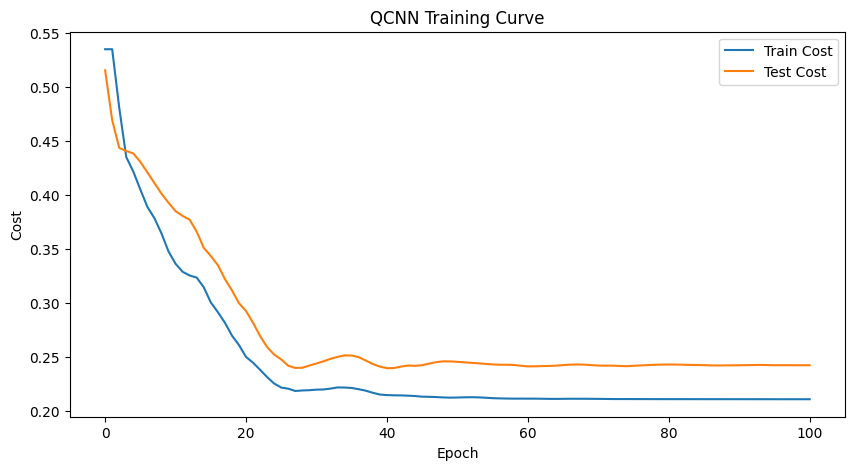

In [ ]:
# Step 5: Plot training curve

plt.figure(figsize=(10, 5))
plt.plot(train_cost_epochs, label="Train Cost")
plt.plot(test_cost_epochs, label="Test Cost")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("QCNN Training Curve")
plt.legend()
plt.show()

<hr>

## Summary

In this worksheet, we explored Quantum Convolutional Neural Networks:

1. **Quantum Convolutional Layers**: Parameterized gates for local feature extraction
2. **Quantum Pooling Layers**: Measurement-based dimensionality reduction
3. **Complete QCNN Architecture**: Combining conv, pooling, and fully connected layers
4. **Training**: Using gradient-based optimization for QCNNs
5. **Generalization Analysis**: Understanding the behavior of QCNNs on small datasets

**Key Takeaways:**
- QCNNs adapt classical CNN concepts to quantum computing
- Convolutional layers extract local features through parameterized gates
- Pooling reduces dimensionality through measurement
- QCNNs can generalize well with limited training data

<hr>

## Discussion Questions

1. How does the quantum pooling differ from classical pooling?
2. What are the advantages of QCNNs over classical CNNs?
3. What challenges might arise when scaling QCNNs to larger images?

<hr>

## Next Steps

Continue to:
- [Worksheet 4: Quantum Kernels](./04_QKM.ipynb) - Kernel methods in quantum space
- [Worksheet 5: Extra Topics](./05_Extra.ipynb) - Advanced topics and real quantum hardware

---

___
<hr>
<img src = "../figs/CC-BY-SA.png" style="height:3em; width:auto"> 
This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/">Creative Commons Attribution-ShareAlike 4.0 International License</a>. </br>

Workshop: Coding the QML Future</br>
Authors: Eileen Kuehn, Gabriel Mejia Ruiz (KIT/SCC)